# Demo 3 — ReMatch on a new species

The first two notebooks work on Balearic wall lizards, whose *ventral scale
mosaic* is isolated by a second preparation step (SAM + structured edges) before
matching. Most species do not need that. Zebras, seals and whale sharks are
matched on the segmented animal directly — the stripes, rings and spots *are*
the pattern — and that is the route this notebook takes.

It is also the notebook to start from with **your own photographs**. There are
two ways in:

| | |
|---|---|
| **Segment first** | Point it at raw field photographs. [Grounded-SAM](https://github.com/IDEA-Research/GroundingDINO) cuts the animal out of each one, prompted by nothing more than the word `"zebra"`. No training, no annotation. |
| **Skip segmentation** | Set `SEGMENT = False`. Your images are used exactly as they are — the fastest way to see whether ReMatch works on your data. |

Everything after that is identical to `demo-1` and `demo-2`: match every pair,
train the pair-level classifier, calibrate an identity-level threshold, then
identify a batch of new photographs and reject the animals that are not in the
gallery.

The bundled example is **8 plains zebras** with four photographs each, plus a
query batch of eleven, six of which are animals the model has never seen.

Segmenting and matching them takes a quarter of an hour or more on a CPU, so for
the bundled zebras the notebook loads precomputed match tables by default and
segments only the few photographs it displays. Set `RUN_MATCHING = True` to do
the whole thing. On your own photographs there is nothing precomputed, and it
always runs in full.

## Configure

In [1]:
import os, sys, json, time
from pathlib import Path

import cv2, numpy as np, pandas as pd, torch, joblib
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))          # run from the repository root

import params.params as params
import utils.demo_utils as D

# SuperPoint pads to a fixed keypoint count with random points, so an unseeded
# run picks a different classifier and a different threshold every time.
D.set_seed(0)

# --------------------------------------------------------------------------
# Everything you need to change is in this cell.
# --------------------------------------------------------------------------
GALLERY_DIR = Path("data/images")            # one sub-directory per individual
QUERY_DIR   = Path("data/new/zebra_demo")    # flat batch of photographs to identify

SEGMENT     = True                           # False -> images are already cropped
CLASSES     = ["zebra"]                      # the text prompt: name the animal

GROUND_TRUTH = Path("data/zebra_demo_ground_truth.json")   # optional, scoring only

TAG         = "zebra"                        # names this run's outputs in results/
ENHANCE     = True                           # CLAHE contrast boost, as the paper does

RUN_MATCHING = False    # False -> use data/precomputed/ when it covers these images
# --------------------------------------------------------------------------

D.ENHANCE_CONTRAST = ENHANCE   # applied to every image before its wireframe

DEVICE  = D.device()
RESULTS = Path(params.RESULTS_FOLDER); RESULTS.mkdir(parents=True, exist_ok=True)

# This notebook keeps its own output names, so running it never overwrites the
# lizard model that demo-1 wrote to results/.
MATCHES_OUT   = RESULTS / f"{TAG}_processed_matches.parquet"
SCALER_OUT    = RESULTS / f"{TAG}_scaler.pkl"
CLF_OUT       = RESULTS / f"{TAG}_best_classification_model.pkl"
META_OUT      = RESULTS / f"{TAG}_logistic_regression_model.pkl"
THRESHOLD_OUT = RESULTS / f"{TAG}_threshold.txt"
TOP10_OUT     = RESULTS / f"top10_results_{TAG}.csv"

# Where matching reads from: the segmentation output, or your images untouched.
if SEGMENT:
    GAL_SRC = Path("data/images-segmented")
    QRY_SRC = QUERY_DIR.parent / f"{QUERY_DIR.name}-segmented"
else:
    GAL_SRC, QRY_SRC = GALLERY_DIR, QUERY_DIR

individuals = sorted(p.name for p in GALLERY_DIR.iterdir() if p.is_dir())
gallery_raw = {i: D.list_images(GALLERY_DIR / i) for i in individuals}
query_raw   = D.list_images(QUERY_DIR)
n_gallery   = sum(len(v) for v in gallery_raw.values())

# The bundled zebras ship with their match tables (scripts/make_demo_matches.py).
# They are used only if they cover exactly these images, so they never apply to
# your own data. Names only - the segmented crops need not exist yet.
crop_name = (lambda p: f"{p.stem}.png") if SEGMENT else (lambda p: p.name)
labelled = [(i, GAL_SRC / i / crop_name(p)) for i in individuals for p in gallery_raw[i]]
query_images = [QRY_SRC / crop_name(p) for p in query_raw]
PRE = Path("data/precomputed")
matches = qpairs = None
if not RUN_MATCHING:
    matches = D.load_precomputed(PRE / f"{QUERY_DIR.name}_matches.parquet", labelled)
    qpairs  = D.load_precomputed(PRE / f"{QUERY_DIR.name}_query_matches.parquet",
                                 labelled, query_images)
PRECOMPUTED = matches is not None and qpairs is not None

print("device       :", DEVICE)
print("segmentation :", f"Grounded-SAM, prompt {CLASSES}" if SEGMENT
                        else "none - images used exactly as they are")
print("individuals  :", len(individuals))
print("gallery      :", n_gallery, "photographs")
print("queries      :", len(query_raw))
print(f"\nto match: {n_gallery*(n_gallery-1)//2} training pairs "
      f"+ {len(query_raw)*n_gallery} query-gallery pairs")
if PRECOMPUTED:
    print(f"loading them from {PRE}/ - set RUN_MATCHING = True to recompute")
else:
    print("matching runs at roughly 1 s per pair on CPU, 0.1 s on a CUDA GPU.")

device       : cpu
segmentation : Grounded-SAM, prompt ['zebra']
individuals  : 8
gallery      : 32 photographs
queries      : 11

to match: 496 training pairs + 352 query-gallery pairs
loading them from data/precomputed/ - set RUN_MATCHING = True to recompute


## The gallery

Raw photographs, straight from the field — background, vegetation, other animals
and all. This is what Grounded-SAM has to make sense of.

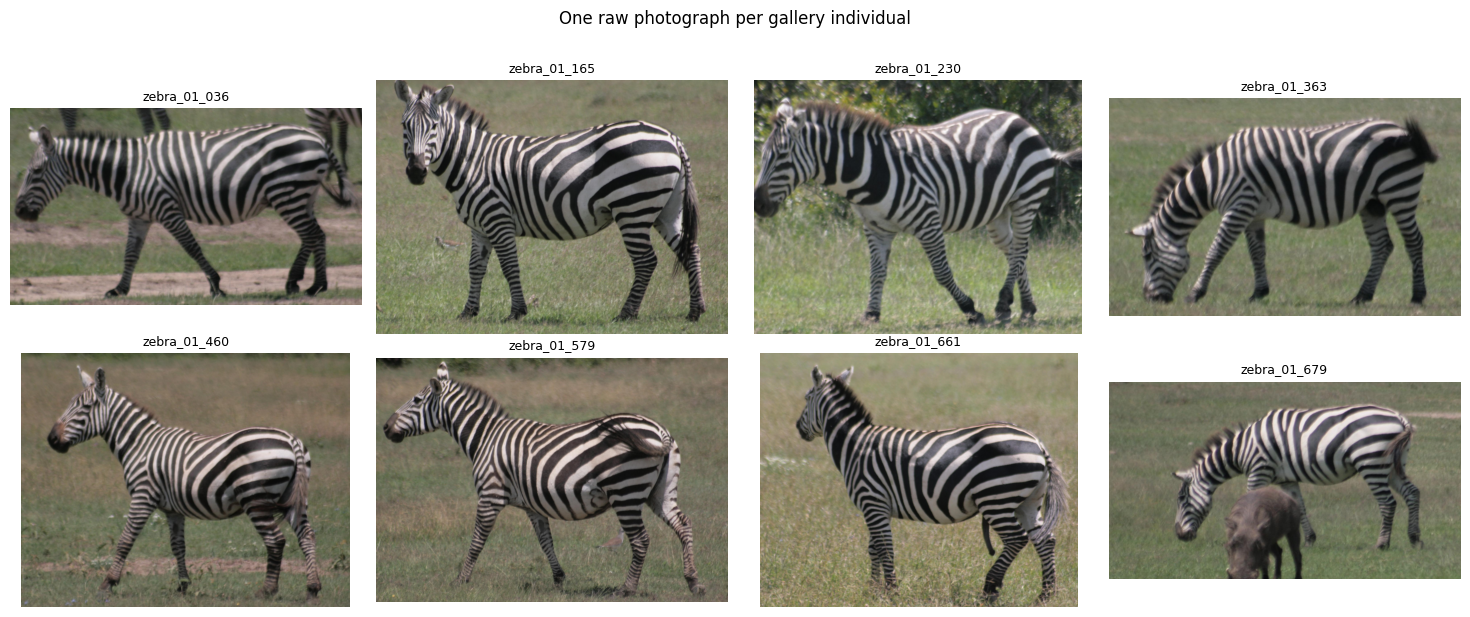

zebra_01_036    4
zebra_01_165    4
zebra_01_230    4
zebra_01_363    4
zebra_01_460    4
zebra_01_579    4
zebra_01_661    4
zebra_01_679    4


In [2]:
show = individuals[:12]                      # a grid that fits however many you have
ncol = min(4, len(show)); nrow = -(-len(show) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.7*ncol, 3.0*nrow), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for ax, ind in zip(axes.ravel(), show):
    ax.imshow(cv2.cvtColor(cv2.imread(str(gallery_raw[ind][0])), cv2.COLOR_BGR2RGB))
    ax.set_title(ind, fontsize=9)
plt.suptitle(f"One raw photograph per gallery individual"
             + (f" (first {len(show)} of {len(individuals)})" if len(show) < len(individuals) else ""),
             y=1.02)
plt.tight_layout(); plt.show()

print(pd.Series({i: len(v) for i, v in gallery_raw.items()},
                name="photographs").to_string())

## Stage 0 — Segmentation

Grounded-SAM is two models in series. GroundingDINO reads the text prompt
`CLASSES` and proposes boxes for anything matching it; SAM turns the best box
into a pixel mask. The animal is cropped to that box and the mask becomes the
image's alpha channel, so everything outside it is transparent.

Nothing here is trained on zebras. Changing `CLASSES` to `["seal"]` or
`["shark"]` is the whole of what adapting to another species requires — which is
why this is the right thing to try first, before considering a fine-tuned YOLO.

**This step needs two weight files in `models/`** — `groundingdino_swint_ogc.pth`
and `sam_vit_h_4b8939.pth` — and the GroundingDINO package, which is not on
PyPI. See the README. It is also slow on CPU: SAM's ViT-H encoder runs on every
photograph. If you set `SEGMENT = False`, none of it is needed.

In [3]:
if SEGMENT:
    # With precomputed matches only the photographs shown below are needed.
    to_segment = ({i: gallery_raw[i][:1] for i in individuals[:4]} if PRECOMPUTED
                  else gallery_raw)
    queries = [] if PRECOMPUTED else query_raw

    t0 = time.time()
    gsam = D.build_grounded_sam(DEVICE)      # loads GroundingDINO + SAM once
    flagged = []
    for ind, raws in to_segment.items():
        print(f"{ind}:")
        _, sk = D.segment_images(gsam, raws, GAL_SRC / ind, CLASSES, DEVICE)
        flagged += sk
    if queries:
        print("query batch:")
        _, sk = D.segment_images(gsam, queries, QRY_SRC, CLASSES, DEVICE)
        flagged += sk

    del gsam; D.empty_device_cache(DEVICE)
    n_done = sum(len(v) for v in to_segment.values()) + len(queries)
    print(f"\nsegmented {n_done} photographs in {(time.time()-t0)/60:.1f} min")
    if PRECOMPUTED:
        print("(only those displayed below - the matches are precomputed)")
    if flagged:
        print("\nneeding a look:")
        for p, why in flagged:
            print(f"  {Path(p).name:<24} {why}")
    else:
        print("nothing flagged.")
else:
    print("SEGMENT = False - skipping segmentation, matching your images directly.")

2026-09-24 13:01:21,173 - INFO - GroundingDINO's compiled C++ ops are not installed; using its pure-PyTorch deformable attention instead (same masks, somewhat slower). Ignore the 'Running on CPU mode Only!' warning above: the GPU is still used for everything else.


final text_encoder_type: bert-base-uncased


zebra_01_036:
  segmenting 1/1  img-0000504.jpg             


zebra_01_165:
  segmenting 1/1  img-0000317.jpg             


zebra_01_230:
  segmenting 1/1  img-0000677.jpg             


zebra_01_363:
  segmenting 1/1  img-0000469.jpg             


segmented 4 photographs in 1.5 min
(only those displayed below - the matches are precomputed)
nothing flagged.


### Check the masks before going on

A bad mask wastes the whole matching run, and matching is the expensive part.
Look for animals that are cut in half, masks that grabbed the background instead
of the zebra, or crops containing two animals. Delete the failures from the
segmented directory and re-run the cell above — it skips work already done, so
only the deleted ones are recomputed.

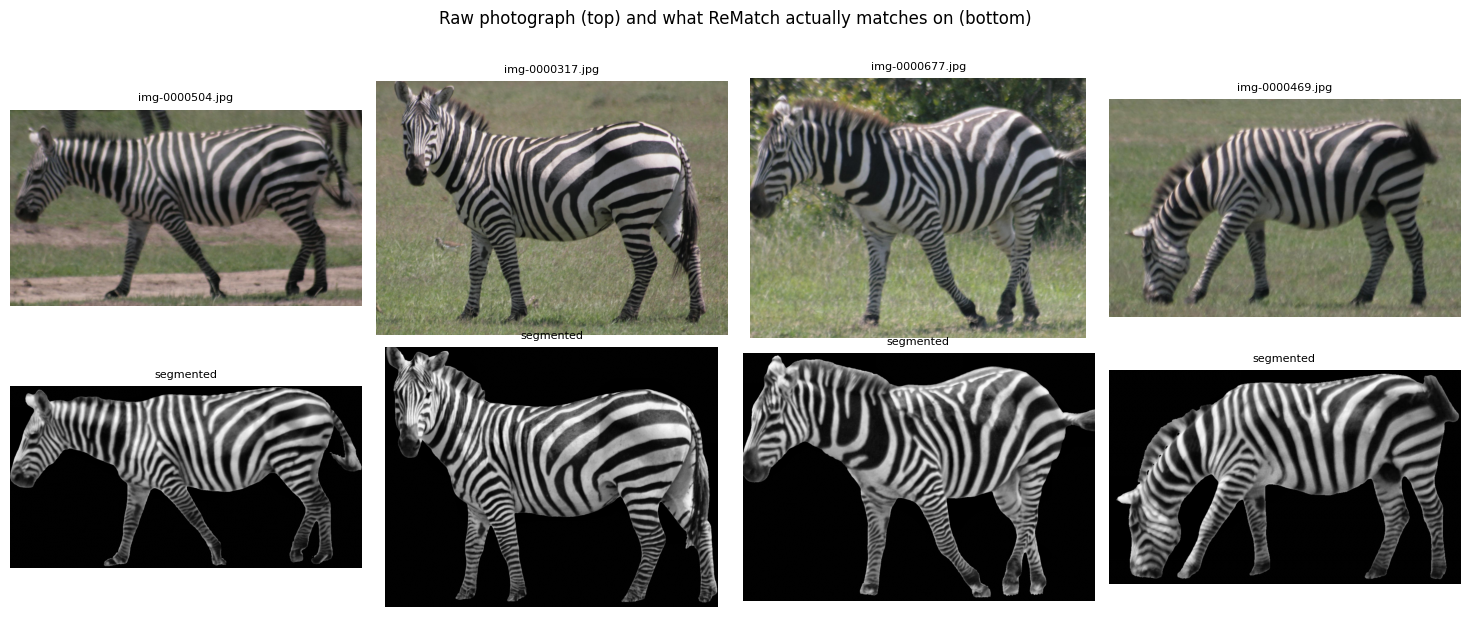

In [4]:
check = individuals[:4]
pairs_to_show = [(gallery_raw[i][0], GAL_SRC / i / f"{gallery_raw[i][0].stem}.png")
                 for i in check]
fig, axes = plt.subplots(2, len(check), figsize=(3.7*len(check), 6), squeeze=False)
for col, (raw, seg) in enumerate(pairs_to_show):
    axes[0, col].imshow(cv2.cvtColor(cv2.imread(str(raw)), cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(raw.name, fontsize=8)
    if seg.exists():
        axes[1, col].imshow(D.load_gray(seg), cmap="gray")
        axes[1, col].set_title("segmented", fontsize=8)
    else:
        axes[1, col].text(.5, .5, "not segmented\n(SEGMENT = False)",
                          ha="center", va="center", fontsize=9)
    axes[0, col].axis("off"); axes[1, col].axis("off")
plt.suptitle("Raw photograph (top) and what ReMatch actually matches on (bottom)", y=1.02)
plt.tight_layout(); plt.show()

## Stage 1 — Match every pair

From here the notebook is the same method as `demo-1`, on whatever the previous
stage produced. Wireframes are extracted once per image and reused across every
pair; only the matching itself is quadratic.

In [5]:
if PRECOMPUTED:
    print(f"{len(labelled)} images -> {len(matches)} pairs, loaded from {PRE}/")
else:
    labelled = [(ind, p) for ind in individuals for p in D.list_images(GAL_SRC / ind)]
    if not labelled:
        raise SystemExit(f"No images under {GAL_SRC}. Did stage 0 run?")
    print(f"{len(labelled)} images -> {len(labelled)*(len(labelled)-1)//2} pairs\n")

    pipeline = D.build_pipeline(DEVICE)
    matches  = D.all_pairs_table(pipeline, labelled, DEVICE)

print(f"\n{len(matches)} pairs: {matches['same'].sum()} same-individual, "
      f"{(~matches['same']).sum()} different")
print(matches.groupby("same")[D.FEATURES].mean().round(3).to_string())

32 images -> 496 pairs, loaded from data/precomputed/

496 pairs: 48 same-individual, 448 different
       num_nonzero_points  mean_point_prob  num_nonzero_lines  mean_line_prob
same                                                                         
False             107.094            0.359             53.879           0.375
True              482.062            0.685            161.333           0.648


## Near-duplicate photographs

Two genuinely different photographs of the same animal share a few hundred
keypoints at best. A pair far above that is usually not two photographs at all —
it is the same image in the gallery twice: a burst frame, a re-import, one file
saved under two names. Left in, it teaches the classifier that same-individual
pairs look near-identical, which is a comparison it will never meet in the field.

`scripts/P3-feature_aggregation.py` drops these before training and so does the
cell below. Of each flagged pair one copy is removed and one is kept, so the
animal still has a photograph in the gallery. Look at the pairs it prints: the
threshold is a heuristic, and you are the one who can tell a duplicate from a
genuinely tight match.

In [6]:
matches, dropped, dups = D.drop_duplicate_images(matches)

if dropped:
    print(f"{len(dups)} pair(s) above {D.DUPLICATE_POINT_THRESHOLD} matched points:\n")
    for _, r in dups.sort_values("num_nonzero_points", ascending=False).iterrows():
        print(f"  {r.num_nonzero_points:5.0f} pts   {r.img1_full}   <->   {r.img2_full}")
    print(f"\nremoving {len(dropped)} image(s), keeping the other copy of each:")
    for d in dropped:
        print(f"  {d}")
    print(f"\n{len(matches)} pairs left "
          f"({matches['same'].sum()} same-individual, {(~matches['same']).sum()} different)")
    D.show_duplicate_pairs(dups, GAL_SRC)
else:
    print(f"No pair exceeds {D.DUPLICATE_POINT_THRESHOLD} matched points - "
          "no near-duplicates in this gallery.")

matches.to_parquet(MATCHES_OUT, index=False)

No pair exceeds 900 matched points - no near-duplicates in this gallery.


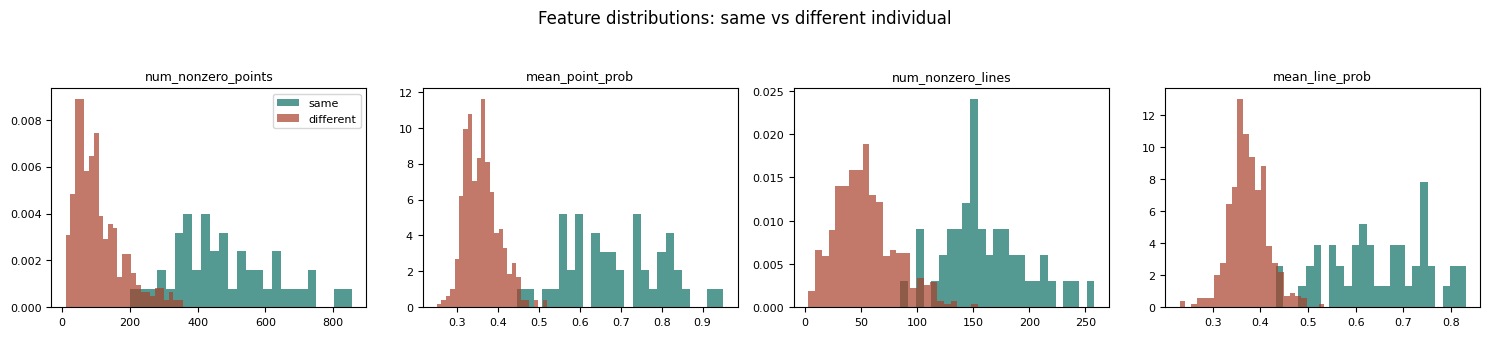

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, f in zip(axes, D.FEATURES):
    for flag, label, colour in [(True, "same", "#0d6e66"), (False, "different", "#a8412a")]:
        ax.hist(matches.loc[matches["same"] == flag, f], bins=25, alpha=.7,
                label=label, color=colour, density=True)
    ax.set_title(f, fontsize=9); ax.tick_params(labelsize=8)
axes[0].legend(fontsize=8)
plt.suptitle("Feature distributions: same vs different individual", y=1.04)
plt.tight_layout(); plt.show()

## Stage 2 — The pair-level classifier

Four candidates over image-disjoint folds; the best mean F1 wins. Image-disjoint
matters: a pair shares its two photographs with many other pairs, so splitting
on pairs would leak.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

images   = pd.Series(pd.unique(pd.concat([matches.img1_full, matches.img2_full])))
shuffled = images.sample(frac=1, random_state=42).tolist()
N_FOLDS   = 3
N_HELDOUT = max(2, len(shuffled) // (N_FOLDS * 4))     # scales with your gallery
folds = [shuffled[i*N_HELDOUT:(i+1)*N_HELDOUT] for i in range(N_FOLDS)]
print(f"{len(shuffled)} images, {N_FOLDS} folds of {N_HELDOUT} held out\n")

candidates = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=42),
    "XGBoost": XGBClassifier(learning_rate=.05, n_estimators=150, max_depth=5,
                             subsample=.8, colsample_bytree=.8, eval_metric="auc", random_state=42),
    "CatBoost": CatBoostClassifier(learning_rate=.1, iterations=200, depth=5,
                                   random_state=42, verbose=0),
}

scores = {}
for name, model in candidates.items():
    fold_f1 = []
    for held in folds:
        tr = matches[~matches.img1_full.isin(held) & ~matches.img2_full.isin(held)]
        va = matches[matches.img1_full.isin(held) ^ matches.img2_full.isin(held)]
        if tr.empty or va.empty or va["same"].nunique() < 2:
            continue
        sc = StandardScaler().fit(tr[D.FEATURES])
        model.fit(sc.transform(tr[D.FEATURES]), tr["same"].astype(int))
        fold_f1.append(f1_score(va["same"].astype(int),
                                model.predict(sc.transform(va[D.FEATURES])),
                                average="macro", zero_division=0))
    scores[name] = fold_f1
    print(f"{name:22} per fold {[round(x,3) for x in fold_f1]}  mean {np.mean(fold_f1):.3f}")

best_name = max(scores, key=lambda k: np.mean(scores[k]))
print(f"\nselected: {best_name}")

32 images, 3 folds of 2 held out

Logistic Regression    per fold [1.0, 1.0, 1.0]  mean 1.000


Random Forest          per fold [0.957, 1.0, 1.0]  mean 0.986
XGBoost                per fold [1.0, 1.0, 1.0]  mean 1.000


CatBoost               per fold [1.0, 1.0, 1.0]  mean 1.000

selected: Logistic Regression


In [9]:
scaler = StandardScaler().fit(matches[D.FEATURES])
clf = candidates[best_name].fit(scaler.transform(matches[D.FEATURES]), matches["same"].astype(int))
matches["p"] = clf.predict_proba(scaler.transform(matches[D.FEATURES]))[:, 1]
print(matches.groupby("same")["p"].describe()[["mean", "50%", "max"]].round(3).to_string())

        mean    50%    max
same                      
False  0.008  0.001  0.171
True   0.928  0.999  1.000


## Stage 3 — The meta-model and τ\*

A query is compared against every photograph of a candidate individual, so the
pair probabilities have to be aggregated into one identity-level score. If the
best score falls below **τ\***, the query is reported as a new animal — this is
what makes ReMatch open-set.

tau* = 0.03   (F1 = 1.000)


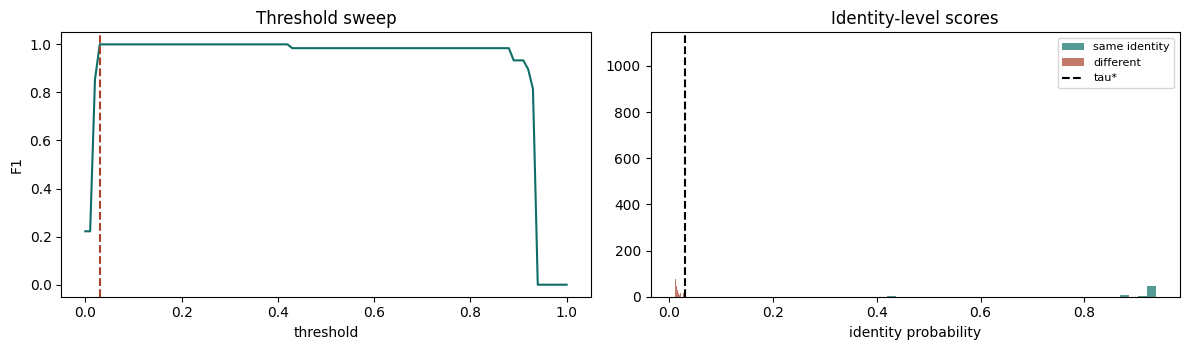


model saved as results/zebra_*  (Logistic Regression, tau* = 0.03)


In [10]:
sym = pd.concat([
    matches.rename(columns={"img1_full": "q", "id2": "cand"})[["q", "cand", "p", "id1"]],
    matches.rename(columns={"img2_full": "q", "id1": "cand"})[["q", "cand", "p", "id2"]]
           .rename(columns={"id2": "id1"}),
], ignore_index=True)

agg = (sym.groupby(["q", "cand"])
          .agg(p=("p", "max"), mean_predicted_probability=("p", "mean"),
               max_predicted_probability=("p", "max"), true_id=("id1", "first"))
          .reset_index())
agg["same"] = agg["cand"] == agg["true_id"]

META = ["p", "max_predicted_probability", "mean_predicted_probability"]
meta = LogisticRegression(max_iter=1000).fit(agg[META].values, agg["same"].astype(int))
agg["identity_prob"] = meta.predict_proba(agg[META].values)[:, 1]

grid = np.linspace(0, 1, 101)
f1s = [f1_score(agg["same"].astype(int), (agg["identity_prob"] >= t).astype(int),
                zero_division=0) for t in grid]
tau = float(grid[int(np.argmax(f1s))])
print(f"tau* = {tau:.2f}   (F1 = {max(f1s):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(grid, f1s, color="#0d6e66"); ax[0].axvline(tau, ls="--", c="#a8412a")
ax[0].set_xlabel("threshold"); ax[0].set_ylabel("F1"); ax[0].set_title("Threshold sweep")
for flag, label, colour in [(True, "same identity", "#0d6e66"), (False, "different", "#a8412a")]:
    ax[1].hist(agg.loc[agg["same"] == flag, "identity_prob"], bins=30, alpha=.7,
               label=label, color=colour, density=True)
ax[1].axvline(tau, ls="--", c="k", label="tau*"); ax[1].legend(fontsize=8)
ax[1].set_title("Identity-level scores"); ax[1].set_xlabel("identity probability")
plt.tight_layout(); plt.show()

joblib.dump(scaler, SCALER_OUT)
joblib.dump(clf,    CLF_OUT)
joblib.dump(meta,   META_OUT)
THRESHOLD_OUT.write_text(str(tau))
print(f"\nmodel saved as {RESULTS}/{TAG}_*  ({best_name}, tau* = {tau})")

## Stage 4 — Identify the query batch

Each new photograph is matched against every gallery image, scored per identity,
and ranked. Anything below τ\* is reported as a new individual rather than
forced onto the nearest known animal.

In [11]:
if not PRECOMPUTED:
    query_images = D.list_images(QRY_SRC)
gallery_images = labelled
print(f"{len(query_images)} queries x {len(gallery_images)} gallery images "
      f"= {len(query_images)*len(gallery_images)} matches\n")

if PRECOMPUTED:
    print(f"loaded from {PRE}/ - set RUN_MATCHING = True to recompute")
else:
    qpairs = D.query_vs_gallery_table(pipeline, query_images, gallery_images, DEVICE)
qpairs["p"] = clf.predict_proba(scaler.transform(qpairs[D.FEATURES]))[:, 1]

ident = (qpairs.groupby(["query", "id2"])
               .agg(p=("p", "max"), max_predicted_probability=("p", "max"),
                    mean_predicted_probability=("p", "mean"))
               .reset_index())
ident["identity_prob"] = meta.predict_proba(ident[META].values)[:, 1]

top10 = (ident.sort_values(["query", "identity_prob"], ascending=[True, False])
              .groupby("query").head(10).reset_index(drop=True))
top10.to_csv(TOP10_OUT, index=False)

best = top10.groupby("query").first().reset_index()
best["prediction"] = np.where(best["identity_prob"] >= tau, best["id2"], "NEW INDIVIDUAL")
print("ranked candidates written to", TOP10_OUT)
best[["query", "id2", "identity_prob", "prediction"]]

11 queries x 32 gallery images = 352 matches

loaded from data/precomputed/ - set RUN_MATCHING = True to recompute
ranked candidates written to results/top10_results_zebra.csv


,query,id2,identity_prob,prediction
0,img-0000144.png,zebra_01_460,0.937318,zebra_01_460
1,img-0000321.png,zebra_01_165,0.895233,zebra_01_165
2,img-0000325.png,zebra_01_460,0.014346,NEW INDIVIDUAL
3,img-0000326.png,zebra_01_165,0.015223,NEW INDIVIDUAL
4,img-0000366.png,zebra_01_579,0.012680,NEW INDIVIDUAL
5,img-0000368.png,zebra_01_679,0.012705,NEW INDIVIDUAL
6,img-0000473.png,zebra_01_363,0.937638,zebra_01_363
7,img-0000508.png,zebra_01_036,0.928764,zebra_01_036
8,img-0000681.png,zebra_01_230,0.937647,zebra_01_230
9,img-0000713.png,zebra_01_579,0.013815,NEW INDIVIDUAL


### Score it

Only possible because this demo ships a ground-truth file. On your own data
there is none — that is what the review step is for: `results/top10_results_<TAG>.csv`
ranks candidates for an expert, it does not decide identities.

In [12]:
if GROUND_TRUTH.exists():
    truth = json.load(open(GROUND_TRUTH))
    qdf = pd.DataFrame(truth["query"]).rename(columns={"image": "query_raw"})
    qdf["query"] = qdf["query_raw"].map(lambda s: Path(s).stem)
    scored = best.assign(stem=best["query"].map(lambda s: Path(s).stem)) \
                 .merge(qdf, left_on="stem", right_on="query", suffixes=("", "_t"))

    known, unknown = scored[scored["in_gallery"]], scored[~scored["in_gallery"]]
    rank = top10.assign(stem=top10["query"].map(lambda s: Path(s).stem)) \
                .merge(qdf, left_on="stem", right_on="query", suffixes=("", "_t"))
    rank["hit"] = rank["id2"] == rank["true_identity"]
    rank["r"]   = rank.groupby("query").cumcount() + 1

    top1 = (known["id2"] == known["true_identity"]).mean()
    top5 = (rank[rank["in_gallery"]].groupby("query")
                .apply(lambda g: bool(g["hit"].any() and g.loc[g["hit"], "r"].min() <= 5),
                       include_groups=False).mean())
    accepted = (known["identity_prob"] >= tau).mean()
    rejected = (unknown["identity_prob"] < tau).mean()
    correct  = int(((known["id2"] == known["true_identity"]) & (known["identity_prob"] >= tau)).sum()
                   + (unknown["identity_prob"] < tau).sum())

    print(f"CLOSED-SET  (n={len(known)})")
    print(f"  Top-1 accuracy             {top1:6.1%}")
    print(f"  Top-5 accuracy             {top5:6.1%}")
    print(f"\nOPEN-SET")
    print(f"  known accepted             {accepted:6.1%}   ({len(known)} queries)")
    print(f"  unknown correctly rejected {rejected:6.1%}   ({len(unknown)} queries)")
    print(f"  overall                    {correct/len(scored):6.1%}   ({correct}/{len(scored)})")
    print(f"\n{len(labelled)} gallery photographs of {len(individuals)} animals is a smoke")
    print("test, not a benchmark - far too small to conclude anything from.")
    if TAG == "zebra":
        print("On the full Plains Zebra dataset (813 images, 45 individuals) the paper")
        print("reports 94.50% Top-1, 98.00% Top-5 and 93.40% open-set accuracy.")
else:
    print(f"No ground truth at {GROUND_TRUTH} - nothing to score against.")
    print("Review the ranked candidates by eye instead.")

CLOSED-SET  (n=5)
  Top-1 accuracy             100.0%
  Top-5 accuracy             100.0%

OPEN-SET
  known accepted             100.0%   (5 queries)
  unknown correctly rejected 100.0%   (6 queries)
  overall                    100.0%   (11/11)

32 gallery photographs of 8 animals is a smoke
test, not a benchmark - far too small to conclude anything from.
On the full Plains Zebra dataset (813 images, 45 individuals) the paper
reports 94.50% Top-1, 98.00% Top-5 and 93.40% open-set accuracy.


## Using this on your own photographs

1. Put your images in `data/images/<individual>/`, one directory per animal —
   **the directory name is the identity label**. Four or more photographs each
   is a reasonable starting point.
2. Put the batch you want to identify in `data/new/<batch>/`, flat.
3. In the config cell, set `GALLERY_DIR`, `QUERY_DIR`, `CLASSES` (the word that
   describes your animal), `TAG` (a short name for your species — it prefixes
   everything this notebook writes to `results/`, so different species do not
   overwrite each other), and `GROUND_TRUTH = Path("nothing")` if you have none.
4. If your images are already cropped to the animal, set `SEGMENT = False` and
   skip the weights entirely.
5. Run the notebook.

Remember that matching cost grows with the **square** of the gallery: 50
photographs is 1 225 pairs, 200 is 19 900, 500 is 124 750. Past a few hundred
images use `scripts/` instead of this notebook — it caches wireframes and
matches to disk and resumes after an interruption.